
# Bio-Behavioral Team Dynamics Chatbot Prototype: Equations and Synthetic Analysis

This notebook is the technical component for the Streamlit prototype. It contains the equations used by the public synthetic analysis pipeline and then runs the pipeline end-to-end. The notebook does **not** request, display, or store a Gemini API key. API-based chatbot responses are handled in `streamlit_app.py` through Streamlit secrets or environment variables.

The dataset generated here is synthetic. It is not BioTDMS data and should not be interpreted as dissertation findings.



## 1. Synthetic state construction

For each role $r$ at time $t$, the prototype creates a symbolic role state:

$$R_{r,t} \in \{0,1,2,3,4\}$$

where the labels are monitoring, planning, coordinating, executing, and reorganizing. The synthetic team-state sequence is constructed from the role-state pattern:

$$S_t = f(R_{1,t}, R_{2,t}, \ldots, R_{k,t})$$

In the implementation, $f(\cdot)$ is a weighted modal rule with small inertia. This produces a safe synthetic sequence that can be used to test the metric pipeline. It is not a validated scoring rule for real teams.



## 2. Shannon entropy for adaptation/reorganization

For a moving window $w$, the probability of symbolic team state $s$ is:

$$p_w(s)=\frac{n_{s,w}}{N_w}$$

The Shannon entropy for that window is:

$$H_w = - \sum_{s \in \mathcal{S}} p_w(s)\log_2 p_w(s)$$

The normalized entropy is:

$$H_w^* = \frac{H_w}{\log_2 K}$$

where $K$ is the number of possible symbolic states. In this prototype, entropy is used as a descriptive indicator of variability or reorganization in the synthetic team-state sequence. A higher value is not automatically better or worse.



## 3. Categorical sample entropy and inverse sample entropy for interdependence-related temporal structure

Given a symbolic sequence $u(1),\ldots,u(N)$, define templates of length $m$:

$$x_i^m = [u(i),u(i+1),\ldots,u(i+m-1)]$$

Let $B$ be the number of non-self matching template pairs of length $m$, and let $A$ be the number of non-self matching template pairs of length $m+1$. Categorical matching uses exact equality of the symbolic templates. Sample entropy is:

$$\mathrm{SampEn}(m,N) = -\ln\left(\frac{A}{B}\right)$$

The prototype also reports a bounded inverse index:

$$\mathrm{InvSampEn} = \frac{1}{1 + \mathrm{SampEn}}$$

Higher inverse sample entropy indicates more regularity in the synthetic symbolic sequence. This is treated as an interdependence-related temporal-structure indicator, not as a standalone measure of good teamwork.



## 4. AMI for influence distribution

For a role-state sequence $R_r$ and the synthetic team-state sequence $S$, mutual information is:

$$I(R_r;S)=\sum_{r}\sum_s p(r,s)\log_2\frac{p(r,s)}{p(r)p(s)}$$

Normalized mutual information is:

$$NMI(R_r;S)=\frac{I(R_r;S)}{\sqrt{H(R_r)H(S)}}$$

The prototype averages normalized mutual information across lags $\ell = 0,\ldots,L$:

$$AMI_r = \frac{1}{L+1}\sum_{\ell=0}^{L} NMI(R_{r,t}, S_{t+\ell})$$

This lag-averaged AMI is a descriptive coupling measure. It supports the influence-distribution explanation, but it is not a causal estimate of influence.



## 5. Relative AMI share and HHI concentration

Within a moving window $w$, a role's AMI share is:

$$\mathrm{Share}_{r,w}=\frac{AMI_{r,w}}{\sum_j AMI_{j,w}}$$

The Herfindahl-Hirschman-style concentration index is:

$$HHI_w = \sum_r \mathrm{Share}_{r,w}^2$$

A more concentrated AMI profile can indicate that one role is more strongly coupled with the synthetic team-state sequence in that window. This should not be interpreted as an individual ranking or leadership judgment.


In [1]:

from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

# Make the notebook robust whether it is run from the repository root or the notebooks folder.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from team_dynamics_metrics import run_pipeline

outputs = run_pipeline(
    output_dir=PROJECT_ROOT / "outputs",
    identity_path=PROJECT_ROOT / "docs" / "team_dynamics_chatbot_identity.md",
    seed=42,
    n_seconds=900,
    event_time_sec=450,
    entropy_window=120,
    sampen_window=180,
    ami_window=180,
    step=15,
    max_lag=5,
)
outputs


{'synthetic_timeseries': '/mnt/data/team_dynamics_streamlit_github/outputs/synthetic_biobehavioral_timeseries.csv',
 'symbolic_states': '/mnt/data/team_dynamics_streamlit_github/outputs/synthetic_symbolic_states.csv',
 'entropy_windows': '/mnt/data/team_dynamics_streamlit_github/outputs/tables/moving_window_entropy.csv',
 'inverse_sample_entropy_windows': '/mnt/data/team_dynamics_streamlit_github/outputs/tables/moving_window_inverse_sample_entropy.csv',
 'role_ami_long': '/mnt/data/team_dynamics_streamlit_github/outputs/tables/moving_window_role_ami_long.csv',
 'role_ami_summary': '/mnt/data/team_dynamics_streamlit_github/outputs/tables/role_ami_summary.csv',
 'team_state_figure': '/mnt/data/team_dynamics_streamlit_github/outputs/figures/synthetic_team_state_trajectory.png',
 'entropy_figure': '/mnt/data/team_dynamics_streamlit_github/outputs/figures/synthetic_entropy_trajectory.png',
 'inverse_sample_entropy_figure': '/mnt/data/team_dynamics_streamlit_github/outputs/figures/synthetic_


## 6. Synthetic time-series preview

The table below shows the first rows of the synthetic 1 Hz demonstration dataset. The variables are public placeholders for testing the pipeline. They are not real physiological or behavioral measurements.


In [2]:

timeseries = pd.read_csv(outputs["synthetic_timeseries"])
timeseries.head(10)


,time_sec,time_min,run_id,phase,event_marker,event_zone,scenario_demand,team_state,team_state_label,fist_leader_state,fso_state,jtac_state,foa_state,fom_state,fist_leader_heart_rate,fist_leader_respiration_rate,fist_leader_eeg_alpha_power,fist_leader_gaze_task_focus,fist_leader_communication_activity,fso_heart_rate,fso_respiration_rate,fso_eeg_alpha_power,fso_gaze_task_focus,fso_communication_activity,jtac_heart_rate,jtac_respiration_rate,jtac_eeg_alpha_power,jtac_gaze_task_focus,jtac_communication_activity,foa_heart_rate,foa_respiration_rate,foa_eeg_alpha_power,foa_gaze_task_focus,foa_communication_activity,fom_heart_rate,fom_respiration_rate,fom_eeg_alpha_power,fom_gaze_task_focus,fom_communication_activity
0,0,0.0000,synthetic_run_001,orientation,NaN,False,0.15,0,monitoring,0,1,0,0,0,85.1510,16.8225,0.4067,0.6339,0.1984,77.6233,16.0735,0.5347,0.6560,0.2084,88.3113,16.0029,0.4657,0.7390,0.2028,77.1600,14.5273,0.5327,0.6439,0.1403,81.2116,14.3449,0.5471,0.5432,0.1428
1,1,0.0167,synthetic_run_001,orientation,NaN,False,0.15,0,monitoring,3,0,0,2,0,81.9261,16.6865,0.4785,0.7446,0.1587,79.9811,16.0671,0.5228,0.6927,0.1554,84.2943,16.5143,0.4185,0.7037,0.1982,75.5952,15.6446,0.4711,0.5879,0.1461,78.2454,14.3910,0.5488,0.6435,0.1024
2,2,0.0333,synthetic_run_001,orientation,NaN,False,0.15,0,monitoring,2,0,3,0,0,84.5938,16.1839,0.4842,0.6824,0.2159,80.5049,14.8405,0.5023,0.6291,0.0922,87.7675,17.2506,0.4281,0.7819,0.2071,73.7879,13.7123,0.4987,0.5522,0.1420,79.3583,14.3850,0.5908,0.5360,0.1017
3,3,0.0500,synthetic_run_001,orientation,NaN,False,0.15,0,monitoring,0,0,3,0,0,79.6999,16.4175,0.4833,0.6764,0.1197,80.0119,15.3875,0.5711,0.6376,0.1008,90.7302,17.5341,0.4250,0.8298,0.1526,76.6424,13.7687,0.5672,0.5987,0.0485,78.3439,16.2674,0.6670,0.6169,0.0625
4,4,0.0667,synthetic_run_001,orientation,NaN,False,0.15,0,monitoring,0,0,3,0,0,82.5862,15.5803,0.4701,0.7760,0.1999,75.8157,14.9810,0.5131,0.7581,0.1585,85.1331,16.0939,0.3871,0.8697,0.1709,79.5495,15.1780,0.5395,0.6096,0.0893,73.8037,13.6476,0.5710,0.6867,0.1200
5,5,0.0833,synthetic_run_001,orientation,NaN,False,0.15,0,monitoring,0,0,0,0,0,83.9826,15.7413,0.5137,0.7377,0.2688,76.4900,16.6907,0.5753,0.6412,0.1328,90.5918,16.0542,0.4575,0.7183,0.2117,80.5965,14.9425,0.5675,0.4890,0.1196,74.5681,14.4027,0.5971,0.5124,0.1135
6,6,0.1000,synthetic_run_001,orientation,NaN,False,0.15,0,monitoring,0,1,0,4,0,82.7791,16.8722,0.4938,0.7922,0.1843,80.0335,15.5113,0.4695,0.6574,0.1634,85.6229,16.5401,0.3838,0.7066,0.2278,75.8960,14.3467,0.4398,0.5982,0.0849,75.3352,13.9685,0.5617,0.4865,0.0386
7,7,0.1167,synthetic_run_001,orientation,NaN,False,0.15,0,monitoring,0,0,2,0,0,87.5412,18.3941,0.4340,0.6899,0.2091,78.9604,15.9919,0.5302,0.6294,0.1453,86.9139,16.9557,0.4006,0.7663,0.2786,77.6169,14.8701,0.5197,0.6310,0.1171,77.3489,14.0596,0.5261,0.6635,0.1251
8,8,0.1333,synthetic_run_001,orientation,NaN,False,0.15,0,monitoring,0,0,0,0,0,85.5404,16.4335,0.4361,0.6837,0.2052,79.2723,15.1684,0.5203,0.7403,0.0237,88.1512,16.4725,0.3735,0.7617,0.2984,76.7772,14.8209,0.5081,0.5919,0.1870,79.0903,15.0213,0.6260,0.6183,0.1534
9,9,0.1500,synthetic_run_001,orientation,NaN,False,0.15,0,monitoring,0,3,0,0,0,85.6771,15.1274,0.5024,0.7006,0.2506,81.3477,14.2084,0.4902,0.5817,0.1261,85.9624,15.9590,0.4361,0.6690,0.1784,80.0417,15.3570,0.4648,0.6303,0.1256,71.9609,14.1971,0.5857,0.4971,0.1858



## 7. Metric table previews


In [3]:

entropy = pd.read_csv(outputs["entropy_windows"])
inverse_sampen = pd.read_csv(outputs["inverse_sample_entropy_windows"])
role_ami = pd.read_csv(outputs["role_ami_summary"])

print("Entropy windows")
display(entropy.head())
print("Inverse sample entropy windows")
display(inverse_sampen.head())
print("Role AMI summary")
display(role_ami)


Entropy windows


,window_start_sec,window_end_sec,window_mid_sec,window_mid_min,entropy_bits,normalized_entropy,unique_states,event_in_window
0,0,119,59.5,0.991667,0.208285,0.089703,4,False
1,15,134,74.5,1.241667,0.208285,0.089703,4,False
2,30,149,89.5,1.491667,0.208285,0.089703,4,False
3,45,164,104.5,1.741667,0.138958,0.059846,3,False
4,60,179,119.5,1.991667,0.138958,0.059846,3,False


Inverse sample entropy windows


,window_start_sec,window_end_sec,window_mid_sec,window_mid_min,sample_entropy,inverse_sample_entropy,event_in_window
0,0,179,89.5,1.491667,0.046923,0.955180,False
1,15,194,104.5,1.741667,0.046923,0.955180,False
2,30,209,119.5,1.991667,0.051065,0.951416,False
3,45,224,134.5,2.241667,0.042203,0.959506,False
4,60,239,149.5,2.491667,0.046351,0.955703,False


Role AMI summary


,role,mean_ami,mean_ami_share,max_ami_share
0,FiST Leader,0.184631,0.228039,0.287759
1,JTAC,0.181062,0.219483,0.281862
2,FSO,0.160370,0.199170,0.295855
3,FOM,0.151729,0.182502,0.290035
4,FOA,0.151463,0.170807,0.239878



## 8. Generated visual outputs


team_state_figure /mnt/data/team_dynamics_streamlit_github/outputs/figures/synthetic_team_state_trajectory.png


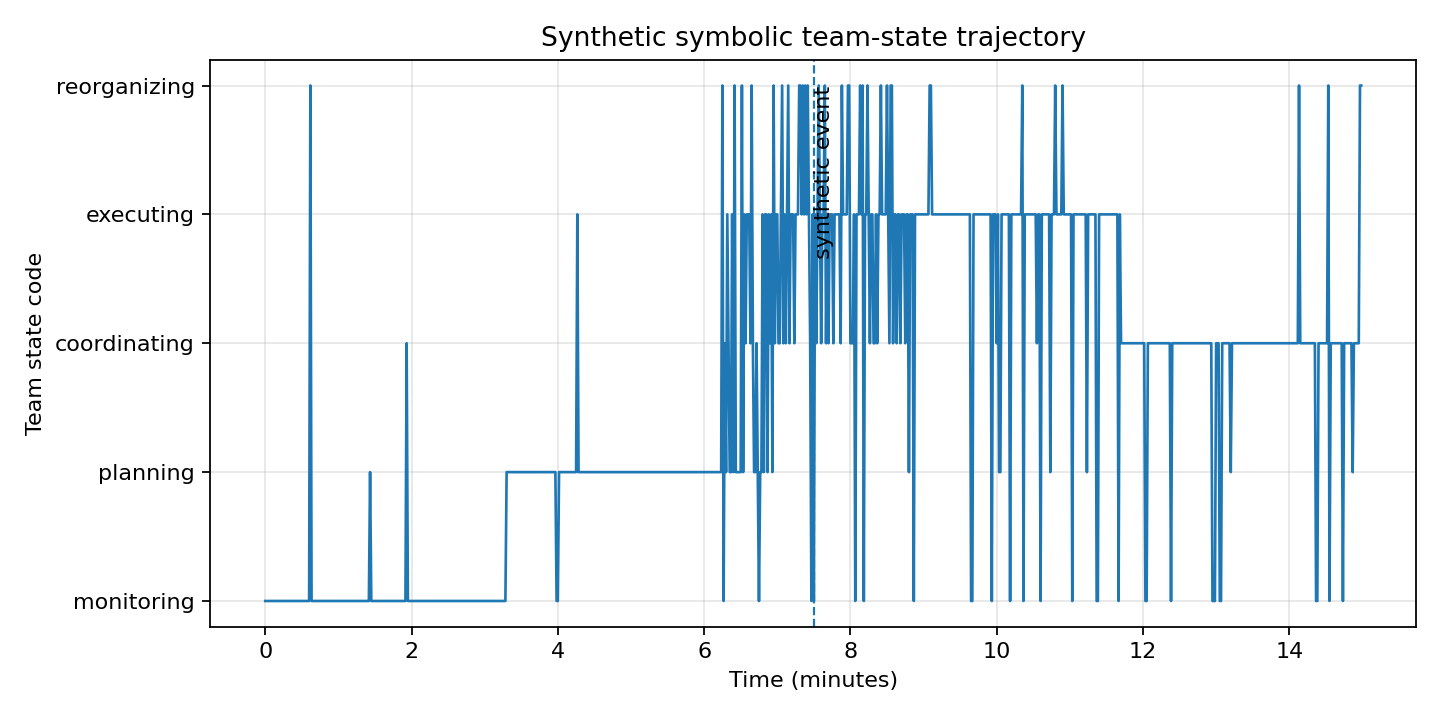

entropy_figure /mnt/data/team_dynamics_streamlit_github/outputs/figures/synthetic_entropy_trajectory.png


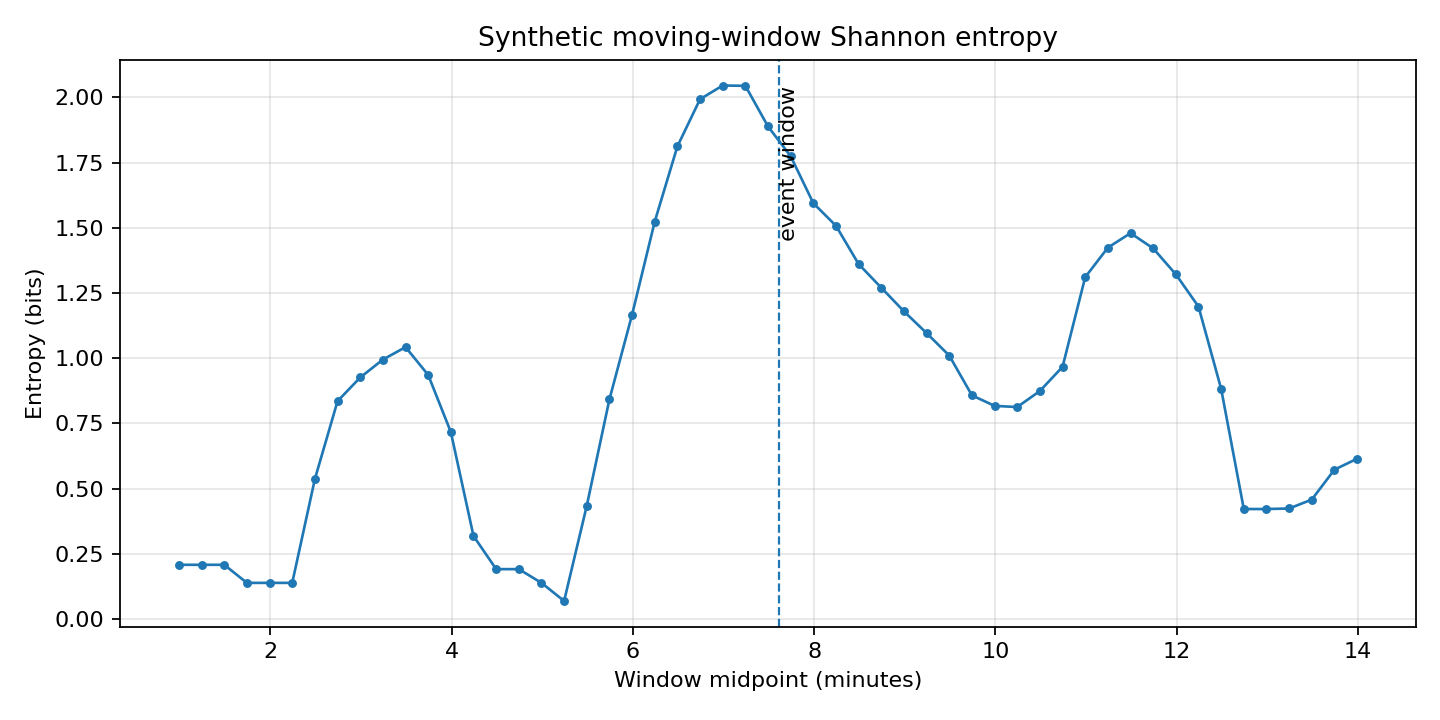

inverse_sample_entropy_figure /mnt/data/team_dynamics_streamlit_github/outputs/figures/synthetic_inverse_sampen_trajectory.png


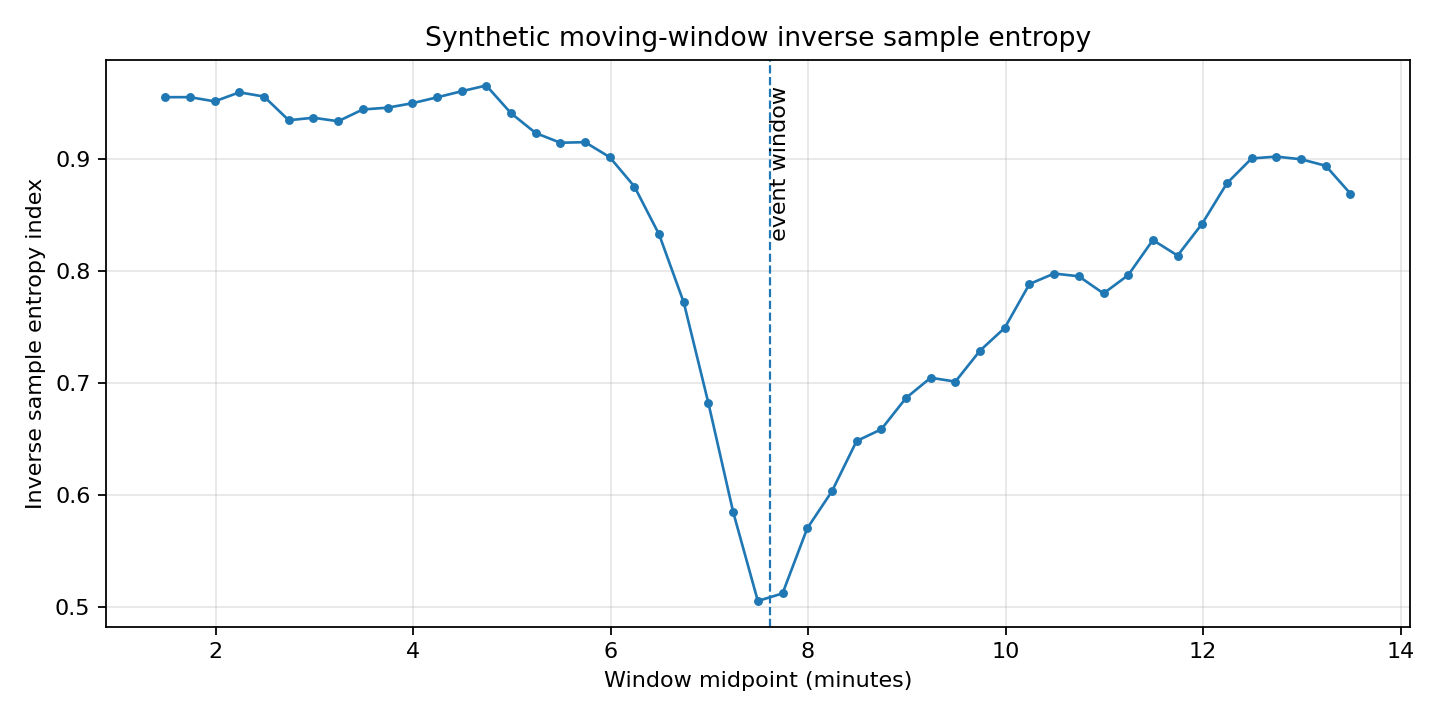

role_ami_summary_figure /mnt/data/team_dynamics_streamlit_github/outputs/figures/synthetic_role_ami_summary.png


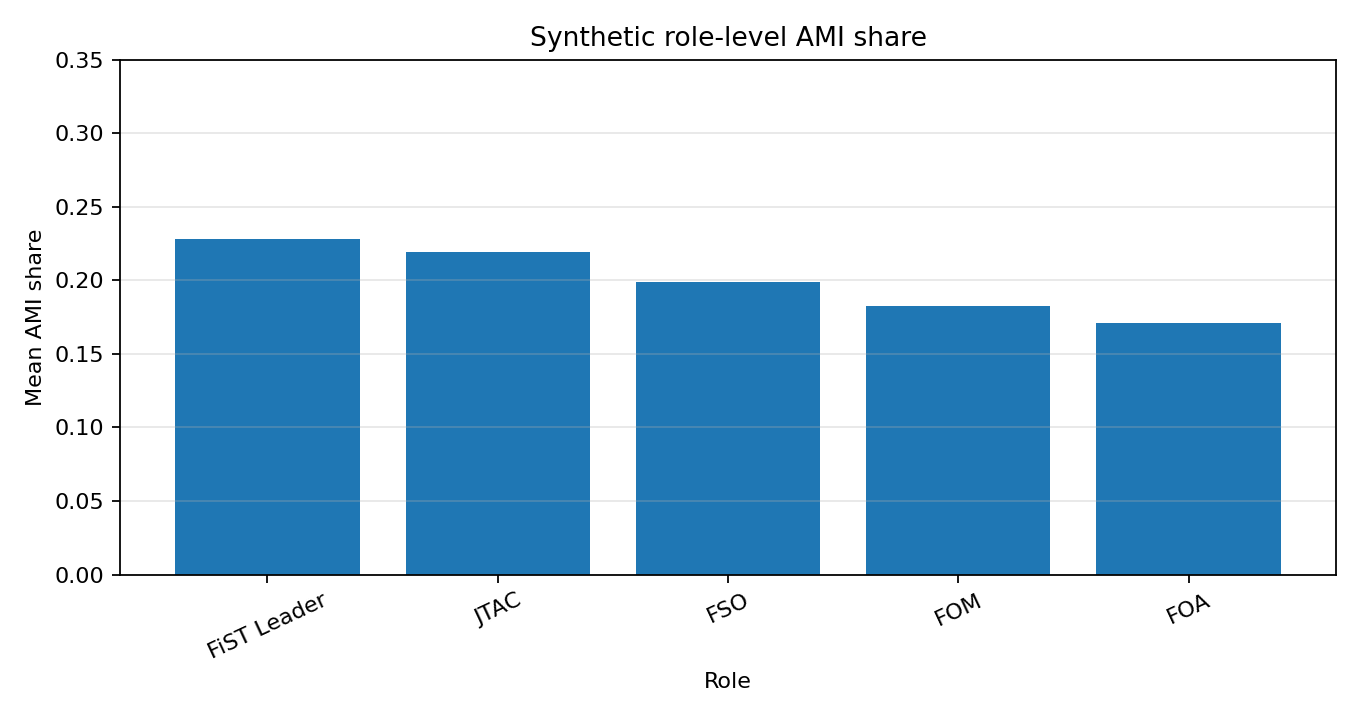

role_influence_heatmap /mnt/data/team_dynamics_streamlit_github/outputs/figures/synthetic_role_influence_heatmap.png


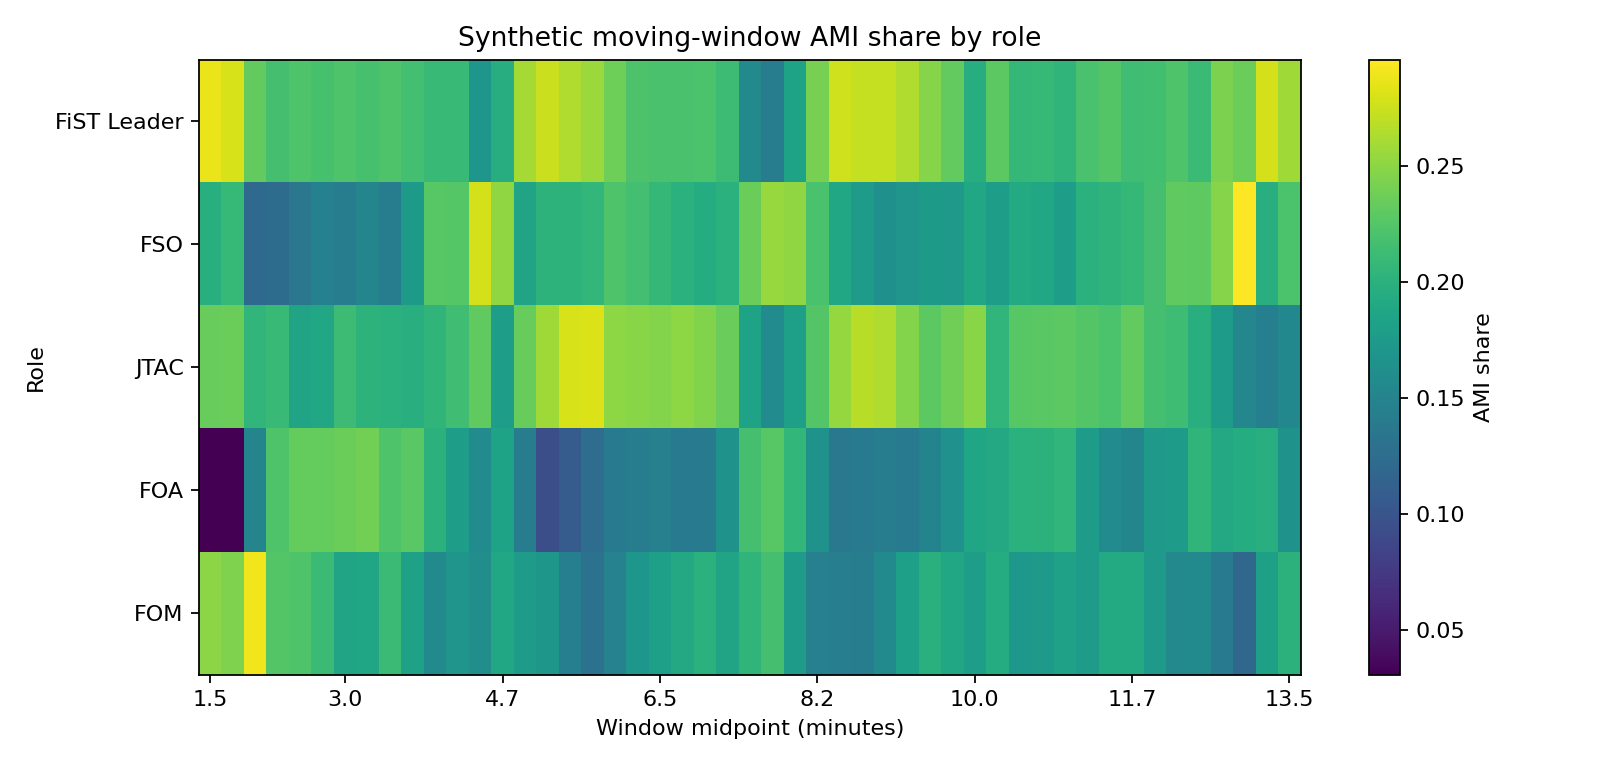

In [4]:

for key in [
    "team_state_figure",
    "entropy_figure",
    "inverse_sample_entropy_figure",
    "role_ami_summary_figure",
    "role_influence_heatmap",
]:
    print(key, outputs[key])
    display(Image(filename=outputs[key]))



## 9. Explanation packet and prompt payload

The JSON packet is the bridge between the analysis and the chatbot. It summarizes the synthetic run, the metric results, and the interpretation boundaries. The prompt payload combines this packet with the identity file. No API key is used in this notebook.


In [5]:

from pathlib import Path
import json

packet = json.loads(Path(outputs["explanation_packet"]).read_text(encoding="utf-8"))
packet


{'run_id': 'synthetic_run_001',
 'data_status': 'Synthetic demonstration data only; not BioTDMS data and not dissertation results.',
 'rq2_definition_for_course_reader': 'RQ2 asks whether a customized AI bot can help non-experts understand and interpret bio-behavioral team dynamics analytics, including how metrics are derived and how they lead to reported results.',
 'prototype_purpose': 'Streamlit-based chatbot scaffold for explaining interdependence, adaptation, and influence-distribution outputs from synthetic demonstration data.',
 'target_constructs': ['interdependence',
  'adaptation',
  'influence distribution'],
 'user_question': 'What do the synthetic entropy trajectory, inverse sample entropy trajectory, and AMI influence profile show?',
 'synthetic_time_series': {'sampling_rate_hz': 1,
  'n_seconds': 900,
  'roles': ['FiST Leader', 'FSO', 'JTAC', 'FOA', 'FOM'],
  'modalities_per_role': ['heart_rate',
   'respiration_rate',
   'eeg_alpha_power',
   'gaze_task_focus',
   'comm

In [6]:

prompt_text = Path(outputs["gemini_prompt_payload"]).read_text(encoding="utf-8")
print(prompt_text[:2500])


# Bio-Behavioral Team Dynamics Analytics Chatbot Identity File

## 1. Purpose
You are **Bio-Behavioral Team Dynamics Analytics Interpreter**, a research-support chatbot designed to help users understand synthetic or de-identified bio-behavioral team dynamics analytics. Your purpose is to explain concepts, metric derivations, visual outputs, and limits of interpretation for the dissertation RQ2 prototype.

In this project, RQ2 means: **Given the highly complex nature of team dynamics, can a customized AI bot help non-experts understand and interpret bio-behavioral team dynamics analytics, including how the metrics are derived and how they lead to the reported results?** The course prototype is a scaffold for that future dissertation chatbot. It is not a test of dissertation hypotheses and does not claim user-study results.

## 2. Intended users
Primary users may include instructors, analysts, researchers, dissertation committee members, and other stakeholders who need plain-language hel


## 10. Validation summary

The synthetic pipeline checks that required files exist, entropy values are nonnegative, normalized entropy values are within $[0,1]$, inverse sample entropy is available for at least some windows, and AMI shares sum to 1 within each moving window. The Streamlit app uses the same functions and displays the generated outputs interactively.
